In [1]:
using IonSim
using QuantumOptics
using PyPlot

In [21]:
function SDF_apply(angle = 0, time = 50.0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ( ẑ - x̂ ) / √2

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    ψ_ion = normalize(ion["g"] -  ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]
return final_state
end


SDF_apply (generic function with 3 methods)

In [22]:
final_state = SDF_apply(π/2, 50.0)
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

Simulating bichromatic displacement...


81×81 Matrix{Float64}:
  1.93787e-12   3.13866e-12  5.02481e-12  …   3.0862e-12    1.90757e-12
  3.02583e-12   4.84296e-12  7.66661e-12      4.76272e-12   2.97906e-12
  4.61377e-12   7.29244e-12  1.14085e-11      7.17344e-12   4.54368e-12
  6.87273e-12   1.0721e-11   1.65676e-11      1.05499e-11   6.77078e-12
  1.00071e-11   1.53995e-11  2.35019e-11      1.51611e-11   9.8631e-12
  1.42531e-11   2.16332e-11  3.26115e-11  …   2.13108e-11   1.40555e-11
  1.9876e-11    2.97607e-11  4.43507e-11      2.93373e-11   1.96123e-11
  2.7166e-11    4.01582e-11  5.92614e-11      3.96163e-11   2.68223e-11
  3.64312e-11   5.32469e-11  7.80289e-11      5.25668e-11   3.59917e-11
  4.79831e-11   6.94957e-11  1.01546e-10      6.86509e-11   4.74271e-11
  ⋮                                       ⋱                 ⋮
 -3.93001e-10  -2.70494e-10  5.05789e-10     -2.52165e-10  -3.83148e-10
 -2.56209e-10  -1.71466e-10  3.56198e-10     -1.59348e-10  -2.49762e-10
 -1.37897e-10  -5.82419e-11  3.32761e-10     -5.0671

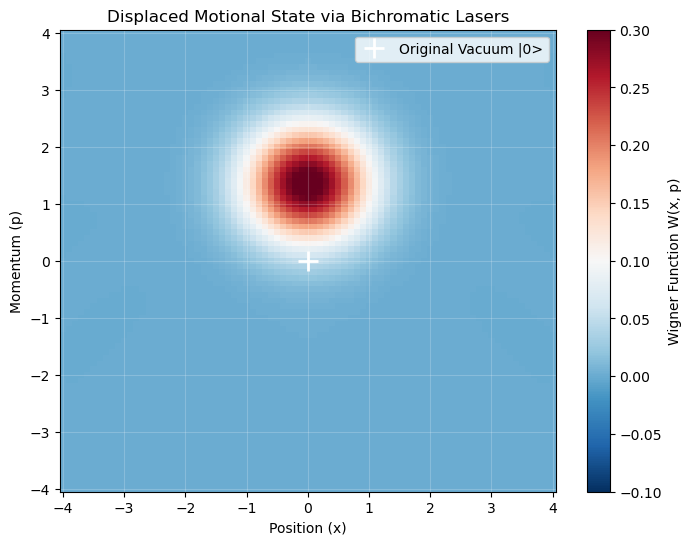

In [23]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


Simulating bichromatic displacement...
Simulating bichromatic displacement...
Simulating bichromatic displacement...
Simulating bichromatic displacement...


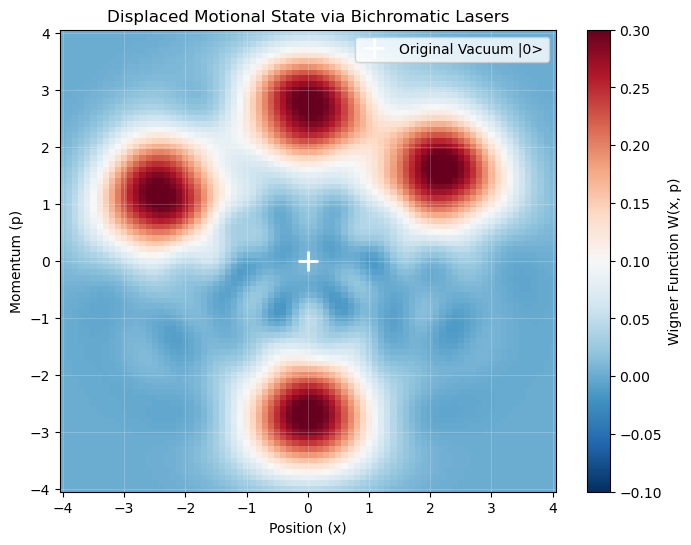

In [26]:
b_fock = FockBasis(10)

final_state1 = SDF_apply(π/2, 100.0)
rho_motional1 = ptrace(final_state1, 1)
rho_fock1 = DenseOperator(b_fock, rho_motional1.data)

final_state2 = SDF_apply(3π/2, 100.0)
rho_motional2 = ptrace(final_state2, 1)
rho_fock2 = DenseOperator(b_fock, rho_motional2.data)

final_state3 = SDF_apply(π/5, 100.0)
rho_motional3 = ptrace(final_state3, 1)
rho_fock3 = DenseOperator(b_fock, rho_motional3.data)

final_state4 = SDF_apply(20*π/7, 100.0)
rho_motional4 = ptrace(final_state4, 1)
rho_fock4 = DenseOperator(b_fock, rho_motional4.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W1 = wigner(rho_fock1, x_vec, p_vec)
W2 = wigner(rho_fock2, x_vec, p_vec)
W3 = wigner(rho_fock3, x_vec, p_vec)
W4 = wigner(rho_fock4, x_vec, p_vec)

W_total = W1 + W2 + W3 + W4

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W_total, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
